# Chapter 3 - Exercise 3: GroupBy

#### drinks.csv là tập tin cung cấp dữ liệu về tình hình tiêu thụ rượu bia ở các quốc gia theo từng châu lục

country: tên quốc gia tiêu thụ<br/>
beer_servings: số lượng bia tiêu thụ<br/>
spirit_servings: số lượng rượu mạnh (>= 40<sup>0</sup>)<br/>
wine_servings: số lượng rượu vang<br/>
total_litres_of_pure_alcohol: tổng số lít rượu nguyên chất<br/>
continent: châu lục  

### Bước 1: Đọc Tập Tin CSV

In [1]:
import pandas as pd

In [2]:
# Câu 1: Đọc dữ liệu từ tập tin drinks.csv, và lưu vào biến drinks. 
drinks = pd.read_csv('drinks.csv')
# Hiển thị một số dòng đầu của tập dữ liệu
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


### Bước 2: Khám Phá Tập Dữ Liệu

In [3]:
# Kiểm tra thông tin cơ bản về tập dữ liệu
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [4]:
# Tính thống kê mô tả cho các cột chứa dữ liệu số
drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


### Bước 3: Xử Lý Dữ Liệu Thiếu

In [5]:
# Đếm dữ liệu NULL
drinks.isnull().sum()

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64

In [6]:
# Hiển thị các dòng bị null
drinks[drinks.isnull().any(axis=1)]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
5,Antigua & Barbuda,102,128,45,4.9,NaN
11,Bahamas,122,176,51,6.3,NaN
14,Barbados,143,173,36,6.3,NaN
17,Belize,263,114,8,6.8,NaN
32,Canada,240,122,100,8.2,NaN
41,Costa Rica,149,87,11,4.4,NaN
43,Cuba,93,137,5,4.2,NaN
50,Dominica,52,286,26,6.6,NaN
51,Dominican Republic,193,147,9,6.2,NaN
54,El Salvador,52,69,2,2.2,NaN


In [7]:
# Những quốc gia có continent bị null là các quốc gia ở North America (NA) nhưng đã bị hiểu nhầm thành nan. Sửa lại cho đúng
drinks.fillna('NA',inplace=True)

In [9]:
# cho biết số lượng quốc gia ở mỗi châu lục
drinks.continent.value_counts()

continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64

### Bước 4: Phân Tích Thống Kê

In [10]:
drinks.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [11]:
# Cho biết thông tin thống kê tổng quát (describe) số lượng rượu vang được tiêu thụ ở mỗi châu lục 
drinks.groupby('continent')['wine_servings'].describe()

,count,mean,std,min,25%,50%,75%,max
continent,,,,,,,,
AF,53.0,16.264151,38.846419,0.0,1.0,2.0,13.00,233.0
AS,44.0,9.068182,21.667034,0.0,0.0,1.0,8.00,123.0
EU,45.0,142.222222,97.421738,0.0,59.0,128.0,195.00,370.0
NA,23.0,24.521739,28.266378,1.0,5.0,11.0,34.00,100.0
OC,16.0,35.625000,64.555790,0.0,1.0,8.5,23.25,212.0
SA,12.0,62.416667,88.620189,1.0,3.0,12.0,98.50,221.0


In [13]:
# Cho biết số lượng bia và rượu tiêu thụ trung bình (mean) ở mỗi châu lục
drinks.groupby('continent')[['beer_servings','wine_servings']].mean()

,beer_servings,wine_servings
continent,,
AF,61.471698,16.264151
AS,37.045455,9.068182
EU,193.777778,142.222222
NA,145.434783,24.521739
OC,89.687500,35.625000
SA,175.083333,62.416667


In [14]:
# Cho biết giá trị trung vị (median) của các loại bia và rượu tiêu thụ ở mỗi châu lục
drinks.groupby('continent')[['beer_servings','wine_servings']].median()

,beer_servings,wine_servings
continent,,
AF,32.0,2.0
AS,17.5,1.0
EU,219.0,128.0
NA,143.0,11.0
OC,52.5,8.5
SA,162.5,12.0


In [16]:
# Cho biết số lượng rượu mạnh (spirit_servings) tiêu thụ trung bình, lớn nhất và nhỏ nhất ở mỗi châu lục
# Chỉ thống kê ở các quốc gia có tiêu thụ rượu mạnh.
drinks[drinks.spirit_servings > 0].groupby('continent')['spirit_servings'].agg(['mean','max','min'])


,mean,max,min
continent,,,
AF,19.681818,152,1
AS,78.735294,326,1
EU,138.720930,373,27
NA,165.739130,438,68
OC,66.785714,254,11
SA,114.750000,302,25


In [17]:
# Sắp xếp dữ liệu tăng dần (sort_values) theo số lượng bia tiêu thụ
drinks.sort_values('beer_servings')

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
13,Bangladesh,0,0,0,0.0,AS
40,Cook Islands,0,254,74,5.9,OC
46,North Korea,0,0,0,0.0,AS
111,Monaco,0,0,0,0.0,EU
...,...,...,...,...,...,...
98,Lithuania,343,244,56,12.9,EU
65,Germany,346,117,175,11.3,EU
62,Gabon,347,98,59,8.9,AF
45,Czech Republic,361,170,134,11.8,EU


In [18]:
# Cho biết 5 quốc gia có lượng tiêu thụ bia ít nhất (khác 0)
drinks[drinks.beer_servings > 0].sort_values('beer_servings').head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
38,Comoros,1,3,1,0.1,AF
73,Haiti,1,326,1,5.9,NA
137,Qatar,1,42,7,0.9,AS
171,Timor-Leste,1,1,4,0.1,AS
168,Tajikistan,2,15,0,0.3,AS


In [19]:
# Cho biết 5 quốc gia ở Châu Á có lượng tiêu thụ bia ít nhất (khác 0)
drinks[(drinks.beer_servings > 0) & (drinks.continent=='AS')].sort_values('beer_servings').head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
171,Timor-Leste,1,1,4,0.1,AS
137,Qatar,1,42,7,0.9,AS
168,Tajikistan,2,15,0,0.3,AS
78,Indonesia,5,1,0,0.1,AS
116,Myanmar,5,1,0,0.1,AS


### Bước 5: Trực Quan Hóa Dữ Liệu 

In [20]:
# Thống kê số lượng quốc gia ở mỗi châu lục
ser = drinks.continent.value_counts()
ser

continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64

<Axes: title={'center': 'số lượng quốc gia ở mỗi châu lục'}, xlabel='continent'>

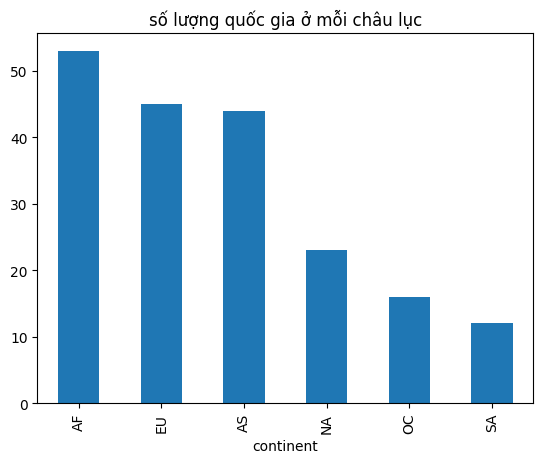

In [22]:
ser.plot.bar(title='số lượng quốc gia ở mỗi châu lục')

In [23]:
# Vẽ biểu đồ Bar với số lượng bia tiêu thụ trung bình ở mỗi châu lục
df = drinks.groupby('continent')[['beer_servings','wine_servings']].mean()
df

,beer_servings,wine_servings
continent,,
AF,61.471698,16.264151
AS,37.045455,9.068182
EU,193.777778,142.222222
NA,145.434783,24.521739
OC,89.687500,35.625000
SA,175.083333,62.416667


<Axes: title={'center': 'số lượng bia tiêu thụ trung bình ở mỗi châu lục'}, xlabel='continent'>

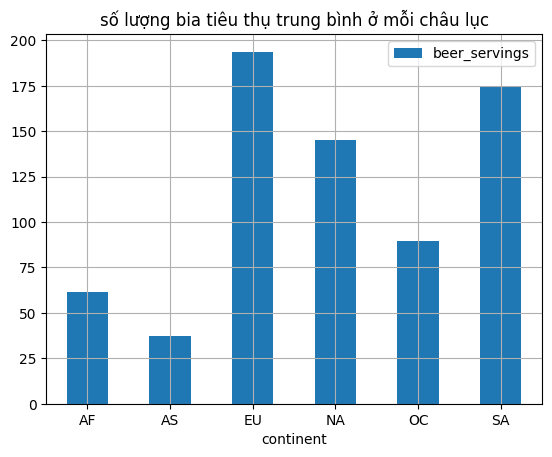

In [25]:
df.plot.bar(y='beer_servings',title='số lượng bia tiêu thụ trung bình ở mỗi châu lục',grid=True,rot=0)

<Axes: title={'center': 'số lượng bia tiêu thụ trung bình ở mỗi châu lục'}, xlabel='continent'>

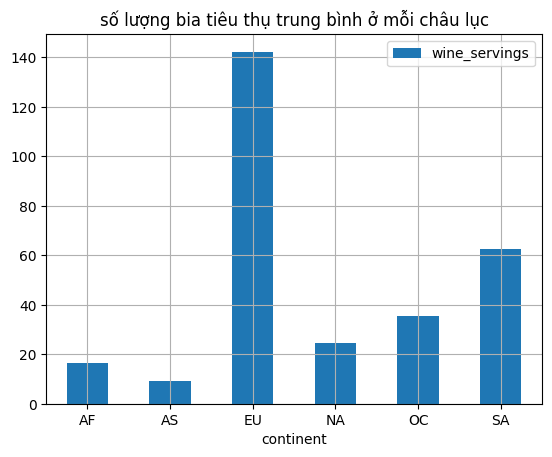

In [26]:
# Vẽ biểu đồ Bar với Tổng lượng rượu mạnh tiêu thụ trên từng châu lục
df.plot.bar(y='wine_servings',title='số lượng bia tiêu thụ trung bình ở mỗi châu lục',grid=True,rot=0)

<Axes: xlabel='continent'>

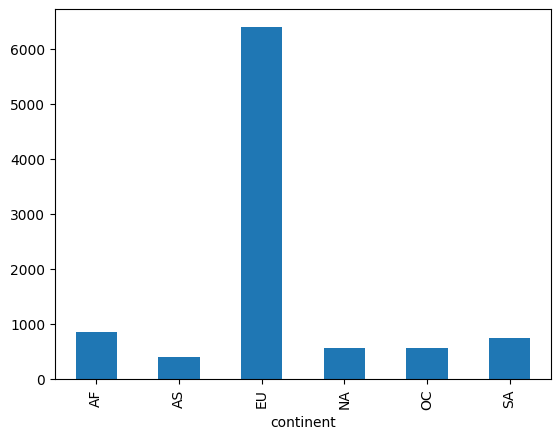

In [28]:
# Vẽ biểu đồ Bar với Tổng lượng rượu vang tiêu thụ trên từng châu lục
ser = drinks.groupby('continent')['wine_servings'].sum()
ser.plot.bar()

<Axes: xlabel='country'>

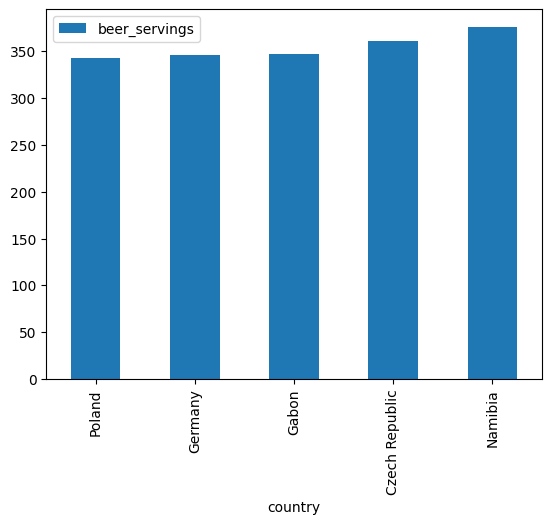

In [30]:
# Vẽ biểu đồ Bar với 5 quốc gia có lượng tiêu thụ bia lớn nhất
drinks[drinks.beer_servings > 0].sort_values('beer_servings').tail().plot.bar(x='country',y='beer_servings')